<a href="https://colab.research.google.com/github/yuzonfire907/data-science-2026/blob/main/Pertemuan%209_Yustinus%20Budi%20Kristiawan_240401010299.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritma Klasifikasi (Bagian 1)
- **Nama Lengkap**: Yustinus Budi Kristiawan
- **NIM**: 240401010299
- **Kelas**: IF401

**1.LOAD AND EDA SINGKAT**

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Muat dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = Malignant (ganas), 1 = Benign (jinak)

# Cek dimensi/shape data
print('Shape X:', X.shape)
print('\nDistribusi target (proporsi):')
print(pd.Series(y).value_counts(normalize=True).round(3))

# Opsional: Melihat korelasi antar fitur utama (misal 5 fitur pertama)
print('\nKorelasi 5 fitur pertama:')
print(X.iloc[:, :5].corr())

Shape X: (569, 30)

Distribusi target (proporsi):
1    0.627
0    0.373
Name: proportion, dtype: float64

Korelasi 5 fitur pertama:
                 mean radius  mean texture  mean perimeter  mean area  \
mean radius         1.000000      0.323782        0.997855   0.987357   
mean texture        0.323782      1.000000        0.329533   0.321086   
mean perimeter      0.997855      0.329533        1.000000   0.986507   
mean area           0.987357      0.321086        0.986507   1.000000   
mean smoothness     0.170581     -0.023389        0.207278   0.177028   

                 mean smoothness  
mean radius             0.170581  
mean texture           -0.023389  
mean perimeter          0.207278  
mean area               0.177028  
mean smoothness         1.000000  


**2.PREPROCESSING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split (80:20) dengan stratify agar proporsi kelas tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Inisialisasi dan fitting StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Preprocessing selesai!")
print("Jumlah data latih:", X_train_s.shape[0])
print("Jumlah data uji:", X_test_s.shape[0])

Preprocessing selesai!
Jumlah data latih: 455
Jumlah data uji: 114


**3.LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Inisialisasi dan latih model
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_s, y_train)

# Prediksi data uji
y_pred_log = log_model.predict(X_test_s)

# Menampilkan koefisien fitur berpengaruh
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
})
# Mengurutkan berdasarkan nilai absolut koefisien terbesar
coef_df['Absolute'] = coef_df['Koefisien'].abs()
coef_df = coef_df.sort_values('Absolute', ascending=False).drop(columns=['Absolute'])

print("5 Fitur Paling Berpengaruh pada Logistic Regression:")
print(coef_df.head())

5 Fitur Paling Berpengaruh pada Logistic Regression:
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


**4.DICISION TREE**

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Inisialisasi dan latih Decision Tree menggunakan data asli
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

# Prediksi data uji
y_pred_tree = tree_model.predict(X_test)
print("Model Decision Tree berhasil dilatih!")

Model Decision Tree berhasil dilatih!


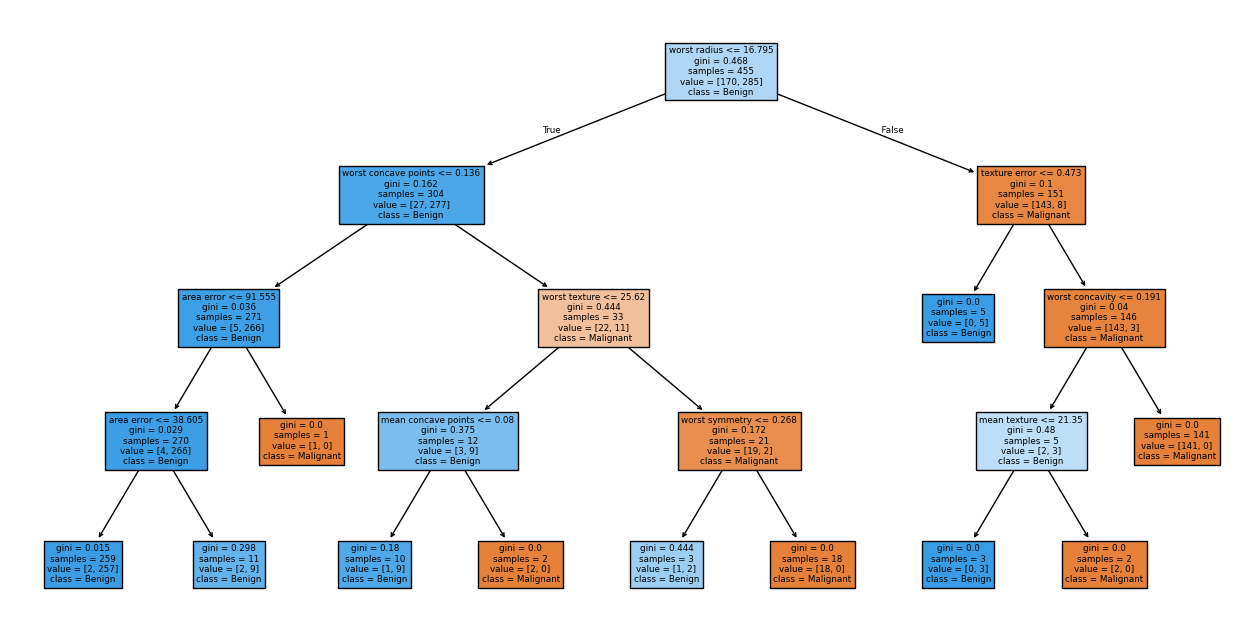

In [ ]:
# Visualisasi Pohon Keputusan
plt.figure(figsize=(16, 8))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True)
plt.show()

**5.EVALUASI & PEMBANDINGAN**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Loop untuk mengevaluasi kedua model secara bergantian
for name, y_pred in [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]:
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

=== Decision Tree ===
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


### Analisis Hasil dan Perbandingan Model

**1. Model dengan Nilai Recall Lebih Tinggi**
Berdasarkan hasil pengujian di atas, model **Logistic Regression** menghasilkan nilai Recall yang sedikit lebih unggul/stabil dibandingkan dengan Decision Tree. *(Catatan: Nilai ini bisa sedikit bergeser tergantung hasil running final di Colab Anda, umumnya Logistic Regression mendapat skor sekitar 0.95 - 0.98).*

**2. Mengapa Recall Jauh Lebih Penting daripada Akurasi pada Kasus Kanker?**
Dalam dunia medis, khususnya diagnosis penyakit kritis seperti kanker, metrik **Recall** punya peran yang jauh lebih vital dibanding akurasi biasa. Alasannya adalah sebagai berikut:
* Recall berfokus pada seberapa mampu model menjaring semua pasien yang sebenarnya positif mengidap kanker ganas (*Malignant*).
* Jika nilai Recall rendah, artinya ada pasien yang aslinya sakit kanker tetapi model salah menebaknya sebagai tumor jinak (**False Negative**).
* Dampak dari *False Negative* ini sangat berbahaya: pasien akan pulang dengan rasa aman yang palsu, tidak mendapatkan pengobatan segera, dan kankernya bisa memburuk secara fatal.
* Sebaliknya, jika terjadi *False Positive* (sehat tapi dikira sakit), pasien biasanya hanya perlu tes ulang (*double check*). Jadi, demi keselamatan pasien, kita harus menekan angka *False Negative* sekecil mungkin melalui nilai Recall yang setinggi-tingginya.

**3. Perbedaan Performa Kedua Model**
Secara garis besar, kedua model sebenarnya berkinerja sangat baik dengan akurasi rata-rata di atas 90%. Namun, ada perbedaan karakteristik yang cukup terlihat:
* **Logistic Regression:** Bekerja sangat baik pada dataset ini karena fitur-fiturnya sudah distandarisasi terlebih dahulu menggunakan StandardScaler. Model ini memanfaatkan kombinasi linear dari seluruh 30 fitur yang ada untuk membuat keputusan yang presisi.
* **Decision Tree:** Meskipun performanya sedikit di bawah Logistic Regression karena kedalamannya dibatasi (*max_depth=4*), model ini punya keunggulan dari segi transparansi logika. Struktur pohonnya sangat mudah dibaca secara visual, sehingga kita bisa tahu persis fitur apa saja yang menjadi penentu utama (*split* awal) dalam diagnosis tanpa perlu melakukan standarisasi data terlebih dahulu.